SETUP OR FETCH our ENV VARIABLES

In [1]:
print("Hello")

Hello


In [2]:
import os

# Groq (model provider)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Search API keys
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

print("Keys set!")


Keys set!


In [3]:
from langchain.chat_models import init_chat_model

# Use Groq LLM
model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",  # Large model for tool calling
    temperature=0.3   # creative 
)

print("LLM initialized:", model)


LLM initialized: output_version=None profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x10d3748d0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10d69a690> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None


SEARCH FUNCTIONALITY

In [4]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily search tool ready")


Tavily search tool ready


In [5]:
tavily_search.invoke({"query": "Give me latest ai news as of 2026"})

{'query': 'Give me latest ai news as of 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.marketingprofs.com/opinions/2026/54530/ai-update-april-10-2026-ai-news-and-views-from-the-past-week',
   'title': 'AI Update, April 10, 2026: AI News and Views From the Past Week',
   'content': 'Meta has introduced Muse Spark, a new AI model designed to power its apps and devices, including Facebook, Instagram, WhatsApp, and smart',
   'score': 0.999608,
   'raw_content': None},
  {'url': 'https://www.youtube.com/watch?v=IjHIE2DMUNg&vl=en',
   'title': '15 New Things AI Can Do in 2026 That Were Impossible Last Year',
   'content': '... artificial intelligence! Our channel delves deep into the latest AI trends and technology, providing insights into cutting-edge AI tools, AI',
   'score': 0.99957937,
   'raw_content': None},
  {'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-march-2026',
   'title': 'The latest AI n

In [6]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print("Google Serper wrapper ready")

Google Serper wrapper ready


/var/folders/6g/rpbc7xxs5vq6wg9thjl5qrt00000gn/T/ipykernel_32911/894811961.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


test google serper

In [7]:
result = google_search.run("best places to visit in Kasol travel guide")
print(result)

Top 10 Places to Visit in Kasol – Explore Himachal's Hidden Gems with NueGo This Winter ___Parvati River. ___Chalal Village. ___Tosh Village. ___Manikaran Sahib. ___Kheerganga Trek. ___Katagla Village. ___Rasol. ___Grahan Village.


In [8]:

def tavily_search_tool(query: str) -> str:
    """
    Search the web using Tavily for travel info, tips, attractions, etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query})


def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travel info.
    """
    return google_search.run(query)



In [9]:
tavily_search_tool("Plan a trip to india")

{'query': 'Plan a trip to india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.foratravel.com/the-journal/planning-a-trip-to-india',
   'title': "A Beginner's Guide to Planning a Trip to India",
   'content': "Wyoming, Montana, and Colorado claim the most celebrated properties—from sprawling all-inclusive ranches in the Rockies to intimate fly-fishing retreats along blue-ribbon trout streams—but you can find experiences across a broad swath of the West, from the Texas Hill Country to the high desert of New Mexico. # A Beginner's Guide to Planning a Trip to India. India has been on my list for *so* long, so finally getting to check it off felt like a dream come true. From the moment I arrived, I was swept up in the sensory overload — vibrant colors, soul-stirring flavors, the hum of bustling people and a culture so rich it leaves you mesmerized. Here’s your beginner’s guide to India — what to expect, where to go and how to fall in love 

In [10]:
# testing the funcitonality 

google_serper_search_tool("Plan a 5 trip to india")

"India Golden Triangle Tour ... Many first-time visitors do a Golden Triangle tour, which visits the three cities of Delhi, Jaipur and Agra, to see the Taj Mahal. Discover the best of India from as little as $1,180. Choose from a wonderful selection of hotels, flights and rental cars to suit your travel style. You can ... We are planning for a 5-6 days trip but kinda not sure on which part of India we should explore. Mostly want to have a quiet time with small treks and good ... For a comfortable and enjoyable tour, plan your visit between October and March. This period offers the best weather for touring various parts of India. Whether ... We spent 5 Days in India's Tourist Triangle (Delhi, Agra, and Jaipur)! In this video we share our experiences in India and give tips to plan ... If you have 5–6 days you can plan a trip to Kerala or Rajasthan or some of the North East Indian states or Punjab and Himachal Pradesh. I've ... Explore India itineraries from 7–14 days. Get inspired and cu

In [11]:
from langchain.agents import create_agent

system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'what to do in Y hotel', etc.
Always use the available web search tools (TavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers.
"""


Travel planner agent ready!


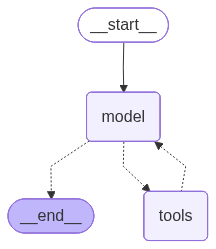

In [12]:
agent = create_agent(
    model=model,
    tools=[tavily_search_tool , google_serper_search_tool],
    system_prompt=system_prompt.strip()  # instructions
)

print("Travel planner agent ready!")
agent

TESTT TIME

In [13]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Give me a 3 day plan for Kasol travel with places to see."}
    ]
})

print("Agent answer:\n")
print(response)


Agent answer:

{'messages': [HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='d5370a19-7cb2-4dcc-a500-04be29bac1c5'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6f2tedacp', 'function': {'arguments': '{"query":"Kasol travel 3 day itinerary"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'e3gfsm7nd', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 391, 'total_tokens': 437, 'completion_time': 0.091123184, 'completion_tokens_details': None, 'prompt_time': 0.030333495, 'prompt_tokens_details': None, 'queue_time': 0.036731592, 'total_time': 0.121456679}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provide

In [14]:
response["messages"]

[HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='d5370a19-7cb2-4dcc-a500-04be29bac1c5'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6f2tedacp', 'function': {'arguments': '{"query":"Kasol travel 3 day itinerary"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'e3gfsm7nd', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 391, 'total_tokens': 437, 'completion_time': 0.091123184, 'completion_tokens_details': None, 'prompt_time': 0.030333495, 'prompt_tokens_details': None, 'queue_time': 0.036731592, 'total_time': 0.121456679}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01

In [15]:
final_answer = response["messages"][-1].content
print(final_answer)

Here's a 3-day plan for your trip to Kasol:

Day 1: 
- Start your day with a visit to Chalal village for a nature walk.
- Have lunch at one of the local cafes in Kasol.
- Explore the Kasol market and visit the Parvati River.

Day 2: 
- Trek to Kheerganga.
- Visit the Tosh village.

Day 3: 
- Visit the Manikaran Sahib.
- Explore the villages of Kalga, Pulga, and Tulga.

This itinerary provides a mix of nature, culture, and adventure, and is a great way to experience the best of Kasol.
